# Ejemplo Series de Tiempo

#### ARIMA / ARMA / SARIMA
Son modelos que nos sirven para que a partir del comportamiendo historico de una serie de tiempo, podamos predecir valores futuros. En otras palabras, sirve especialmente cuando los datos tienen patrones dependientes en el tiempo, y poder modelar y predecir el comportamiento futuro de una serie temporal asumiendo que el pasado tiene una influencia sistemática sobre el futuro.

# 
- AutoRegressive (AR): la serie depende de sus propios valores pasados usando RL.
- Integrated (I): se hacen diferencias para volver la serie estacionaria (quitar tendencia) --> media y varianza no cambien durante el tiempo.
- Moving Average (MA): la serie depende de errores pasados (residuos del modelo). Modela el valor actual y lo compara contra errores del pasado. 

##
Un modelo ARIMA(p, d, q) tiene tres parámetros:
- p → cuántos valores pasados se usan (autoregresivo)
- d → cuántas veces se diferencia la serie (integrado)
- q → cuántos errores pasados se usan (media móvil)

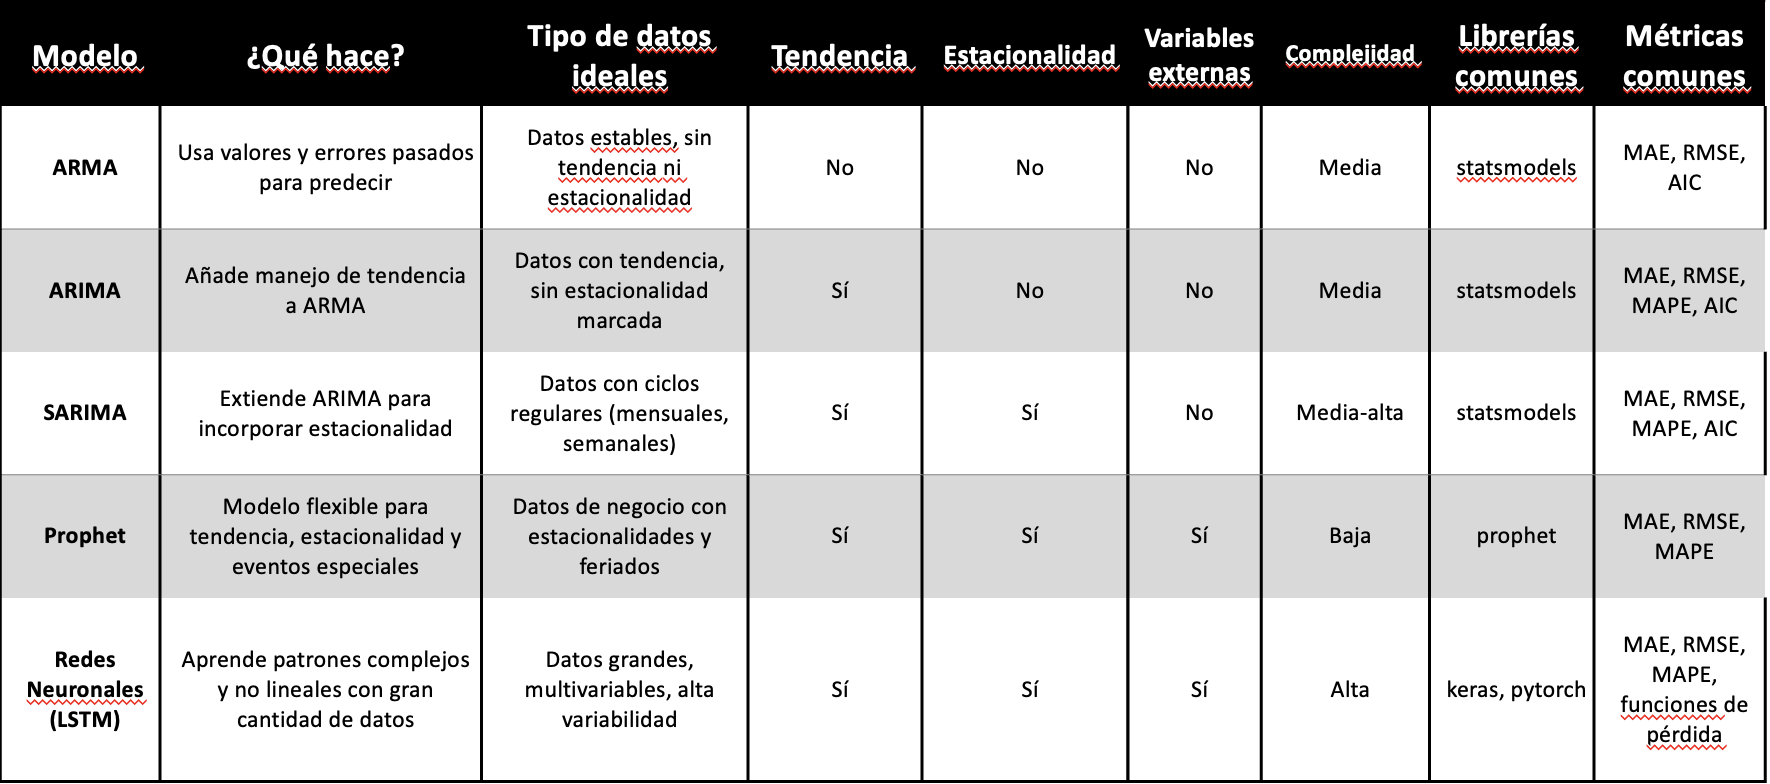

| Componente | Qué hace                                       | Ejemplo conceptual                                     |
| ---------- | ---------------------------------------------- | ------------------------------------------------------ |
| AR (p)     | Usa valores pasados para predecir el actual    | “Si ayer fue alto, hoy también será alto”              |
| I (d)      | Elimina tendencia para hacer la serie estable  | “Resta el valor de ayer para quitar la tendencia”      |
| MA (q)     | Usa errores pasados para ajustar la predicción | “Si el error de ayer fue grande, ajusto la predicción” |


#### Plan de Acción
1. Revisar la estacionariedad: Si la serie no es "estacionable" en media y varianza, se diferencia (parámetro d).

2. Analizar los gráficos de autocorrelación (FAC y FACP): Estos ayudan a identificar los valores apropiados para p y q.

3. Probar diferentes combinaciones de (p,d,q): Se prueban varios modelos para ver cuál ajusta mejor.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [3]:

dateparse = lambda dates: datetime.strptime(dates, '%Y-%m')
airPas = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month',date_parser=dateparse)
print ('\n Parsed Data:')
airPas.head()

train_size = int(len(airPas) * 0.7)
print(train_size)
train_airPas = airPas[0:train_size]
test_airPas = airPas[train_size:len(airPas)]



 Parsed Data:
100


/var/folders/9q/tfydcr6d56x3ht8bfg6vfx240000gn/T/ipykernel_81726/253972542.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  airPas = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month',date_parser=dateparse)


In [4]:
ts_air_pas = train_airPas['#Passengers']
ts_air_pas.head(10)

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
Name: #Passengers, dtype: int64

In [5]:
ts_air_pas[:'1949-5-01']

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64

## Pasos para construir modelos ARIMA
1. Identificación
2. Estimación
3. Validación
4. Predicción

### Identificación


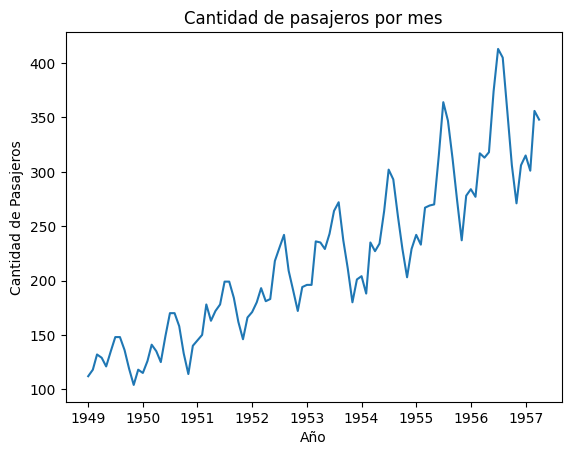

In [6]:
plt.plot(ts_air_pas)
plt.gca().set(title="Cantidad de pasajeros por mes", xlabel="Año", ylabel="Cantidad de Pasajeros")
plt.show()

Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
                 ...    
1956-12-01    328.250000
1957-01-01    330.833333
1957-02-01    332.833333
1957-03-01    336.083333
1957-04-01    339.000000
Name: #Passengers, Length: 100, dtype: float64 Month
1949-01-01          NaN
1949-02-01          NaN
1949-03-01          NaN
1949-04-01          NaN
1949-05-01          NaN
                ...    
1956-12-01    47.861780
1957-01-01    46.058921
1957-02-01    43.983123
1957-03-01    44.147394
1957-04-01    43.636932
Name: #Passengers, Length: 100, dtype: float64


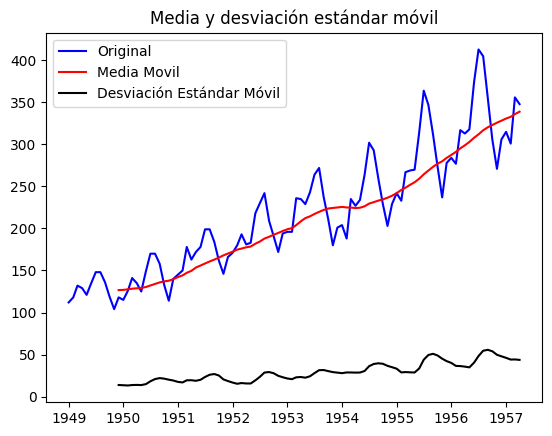

In [7]:
# Se calcula la media móvil y la desviación estandar móvil de los últimos 12 meses.
mediaMovil = ts_air_pas.rolling(window=12).mean()
deMovil = ts_air_pas.rolling(window=12).std()
print(mediaMovil, deMovil)
# Se grafican los resultados.
original = plt.plot(ts_air_pas, color="blue", label="Original")
media = plt.plot(mediaMovil, color='red', label = 'Media Movil')
ds = plt.plot(deMovil,color='black', label = 'Desviación Estándar Móvil')
plt.legend(loc = 'best')
plt.title('Media y desviación estándar móvil')
plt.show(block=False)

En la gráfica se observa que la serie original (línea azul) muestra una tendencia creciente, lo que indica que la media no es constante en el tiempo. La media móvil (línea roja) también va en aumento, reforzando la idea de que la serie probablemente no es estacionaria en media.

Por otro lado, la desviación estándar móvil (línea negra) también parece aumentar a lo largo del tiempo, lo cual sugiere que la varianza tampoco se mantiene constante. Esto es un indicio de que la serie podría no ser estacionaria en varianza (la variabilidad de los datos permanece aproximadamente constante a lo largo del tiempo).

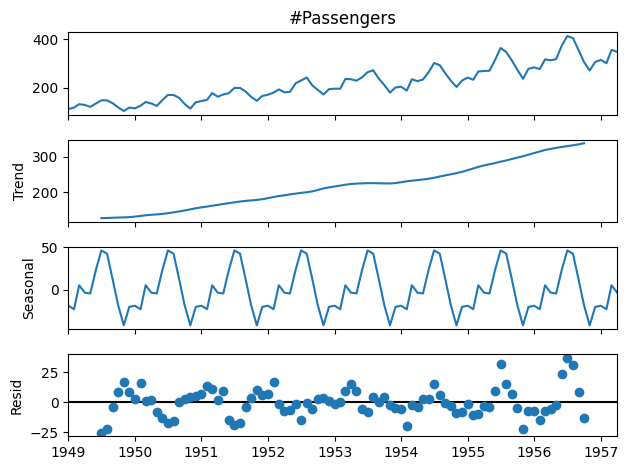

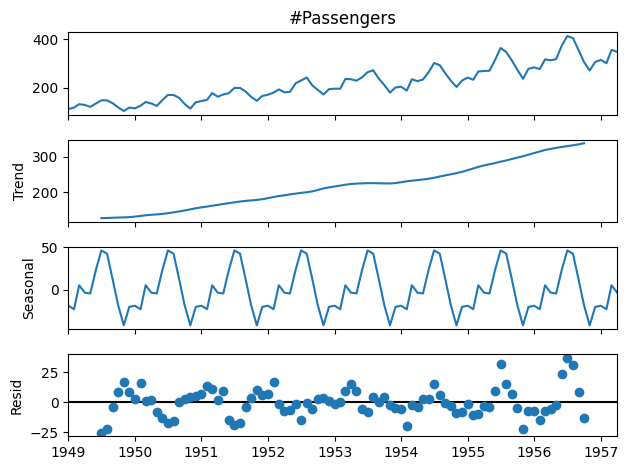

In [8]:
# DESCOMPOSICION ADITIVA
descomposicion = seasonal_decompose(ts_air_pas, model='additive', period=None)
descomposicion.plot()

# Serie Original = Tendencia + Estacionalidad + Ruido (La estacionalidad tiene aproximadamente la misma amplitud durante toda la serie.)
# Serie Original = Tendencia * Estacionalidad * Ruido (Aquí la estacionalidad crece junto con la serie.)

Algunas conclusiones:
- La serie no es estacionaria en media, por la tendencia creciente.
- Tampoco parece estacionaria en varianza, si los residuos se dispersan más en el tiempo.
- Hay estacionalidad clara, lo que te servirá para aplicar modelos como SARIMA.
- Cuando pasa esto, generalmente es necesario aplicar transformaciones con funciones logarítmicas. 

## Estimar los parámetros del modelo

Lo primero que vamos a hacer es estacionarizar la serie. Ya que no es estacionaria en varianza le vamos a aplicar una transformación logaritmica y la volveremos a graficar.
#
¿Por qué queremos estacionarizar la serie? Muchos modelos asumen que los valores estadísticos no cambian en el tiempo.

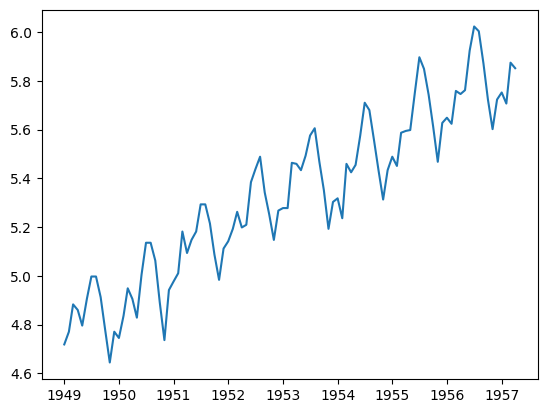

In [9]:
ts_air_pas_log = np.log(ts_air_pas)
plt.plot(ts_air_pas_log)

Con esta transformación pudimos estacionarizarla en varianza. Para validar y ver si no es estacionaria en media (ya sabemos que tiene tendencia a aumentar con el paso del tiempo) aplicaremos la prueba de Dickey-fuller aumentada para comprobar que hay raíces unitarias (que no es estacionaria).

- H₀ (nula): la serie no es estacionaria (tiene raíz unitaria).
- H₁ (alternativa): la serie sí es estacionaria.

In [10]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(ts_air_pas, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         1.509804
p-value                       0.997560
# de retardos usados         12.000000
# de observaciones usadas    87.000000
Critical Value (1%)          -3.507853
Critical Value (5%)          -2.895382
Critical Value (10%)         -2.584824
dtype: float64


¿Qué nos interesa de esto?

- El estadístico: un valor negativo muy grande suele decirnos que podemos rechazar la hipótesis nula.
- p-value: Si p < 0.05, podemos rechazar H₀ y concluir que la serie es estacionaria.
- p-value: Si p > 0.05, no se puede rechazar la hipótesis nula de que existen raices unitarias. 


Entonces? La serie no es estacionaria en media. Vamos a probar con una diferenciación

La diferenciación nos sirve para eliminar la tendencia y hacerla más estacionaria en el tiempo. 
Se calcula como `Yₜ' = Yₜ − Yₜ₋₁`

#
Una serie con una tendencia crecimiente aumenta con el tiempo. Al aplicar diferenciación obtenemos una nueva serie que refleja los cambios mes a mes (las variaciones), no los niveles absolutos.

In [11]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
# # ts_air_pas_diff = ts_air_pas.diff(periods=1) # solo elimina tendencia
# ts_air_pas_diff = ts_air_pas.diff(periods=12) # elimina estacionalidad
ts_air_pas_diff = ts_air_pas.diff(periods=1)
ts_air_pas_diff.dropna(inplace=True)
dfTest = adfuller(ts_air_pas_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba        -2.180602
p-value                       0.213361
# de retardos usados         12.000000
# de observaciones usadas    86.000000
Critical Value (1%)          -3.508783
Critical Value (5%)          -2.895784
Critical Value (10%)         -2.585038
dtype: float64


El p-value es mayor a 0.05, por lo que sigue siendo estacionaria en media. Probemos otra diferenciación

In [12]:
ts_air_pas_diff = ts_air_pas_diff.diff() # .diff(periods = 1)
ts_air_pas_diff.dropna(inplace=True)
dfTest = adfuller(ts_air_pas_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Estadístico de prueba       -1.217795e+01
p-value                      1.372387e-22
# de retardos usados         1.100000e+01
# de observaciones usadas    8.600000e+01
Critical Value (1%)         -3.508783e+00
Critical Value (5%)         -2.895784e+00
Critical Value (10%)        -2.585038e+00
dtype: float64


El objetivo es transformar la serie hasta que sea estacionaria en media
#
Ahora si dio significativo el p-valor, por lo que podemos decir que no hay raices unitarias 



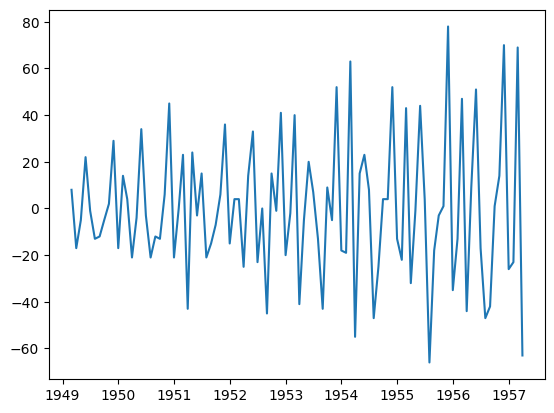

In [13]:
plt.plot(ts_air_pas_diff)

Las transformaciones realizadas fueron una transformación logaritmica y una diferenciación

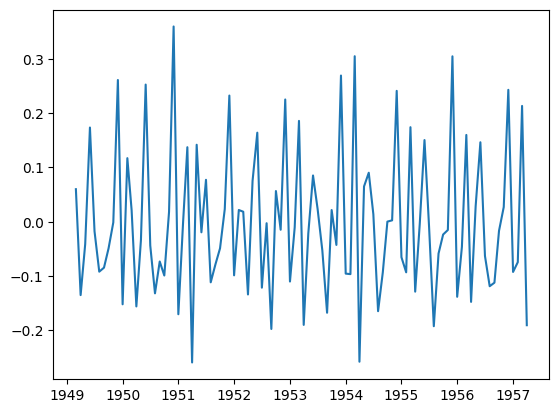

In [14]:
plt.plot(ts_air_pas_log.diff().diff())

Podemos decir que la serie es estacionaria ahora en media y en varianza. Toca ahora estimar los parámetros del modelo.

### Funciones de autocorrelación
#### Modelos teóricos
¿Qué tanto se parece la serie actual a sus valores pasados?
#
Usamos las funciones de autocorrelación (FAC) y autocorrelación parcial (FACP):

#
FAC te sirve para averiguar q

FACP sirve para averiguar p

Para poder elegir el valor p o q, debemos ver en donde se cortan. "Cortar" significa que:

- las primeras barras son significativas,
- y luego todas las demás caen dentro de la banda de confianza (normalmente la zona sombreada en la gráfica).


In [15]:
ts_air_pas_log_diff = ts_air_pas_log.diff().diff()
ts_air_pas_log_diff.dropna(inplace = True)
tsa_acf = acf(ts_air_pas_log_diff,nlags=5,fft=False)
tsa_pacf = pacf(ts_air_pas_log_diff, nlags=36)
tsa_acf

array([ 1.        , -0.32245025, -0.20543664,  0.15191504, -0.26964344,
        0.04263246])

In [16]:
tsa_pacf

array([  1.        ,  -0.32577448,  -0.35334582,  -0.06501566,
        -0.39760573,  -0.29111236,  -0.0825835 ,   0.07625158,
        -0.34795553,  -0.07601706,  -0.46923404,  -1.05161296,
         4.53005214,   0.90673474,   0.23584216,   0.54698475,
         0.6917344 ,   2.06337762,  -1.52849017,  -0.49711391,
        -0.40134398,  -0.63737565,  -0.82158745,  -2.62732829,
         1.60043204,   0.55615503,   0.60213737,   0.47621469,
         0.70930025,   1.87325593,  -1.62015324,  -0.51040316,
        -0.20691257,  -0.9138193 ,  -0.92528715, -16.22506916,
         1.05500608])

Interpretamos:
- Dentro de la banda → la correlación no es estadísticamente significativa.
- Fuera de la banda → la correlación sí es significativa.

Tenemos que ver en donde se "corta". Esto significa que:

las primeras barras son significativas,
y luego todas las demás caen dentro de la banda de confianza (normalmente la zona sombreada en la gráfica).

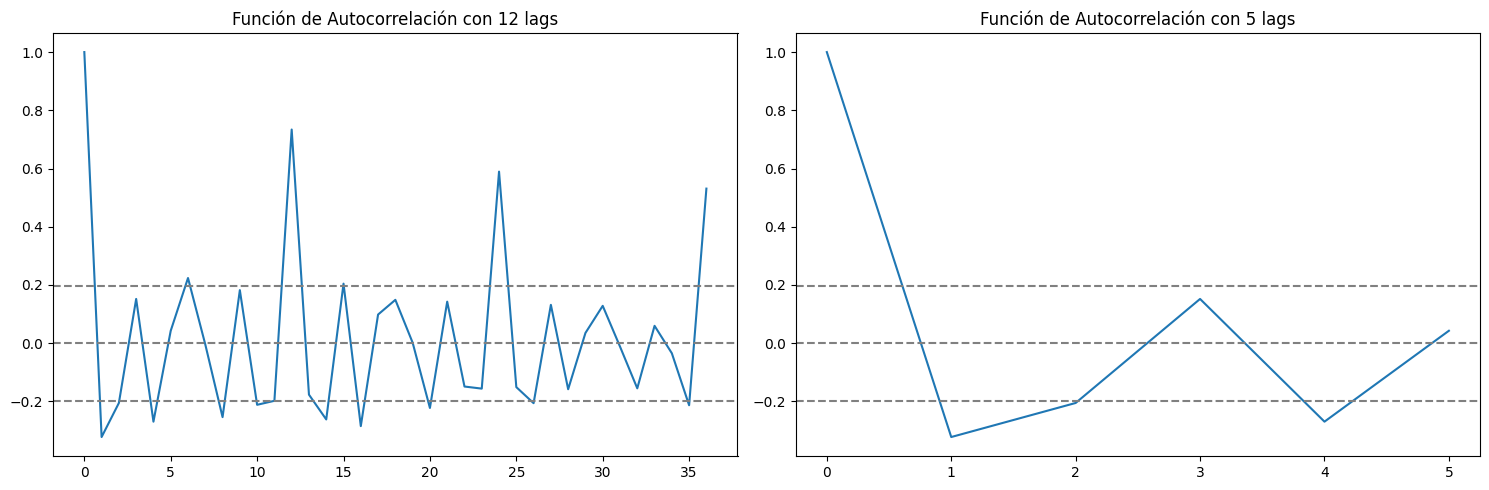

In [17]:

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

#Plot ACF: 
plt.subplot(121) 
plt.plot(acf(ts_air_pas_log_diff,nlags=36,fft=False))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación con 12 lags')

plt.subplot(122) 
plt.plot(acf(ts_air_pas_log_diff,nlags=5,fft=False))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación con 5 lags')

plt.tight_layout()

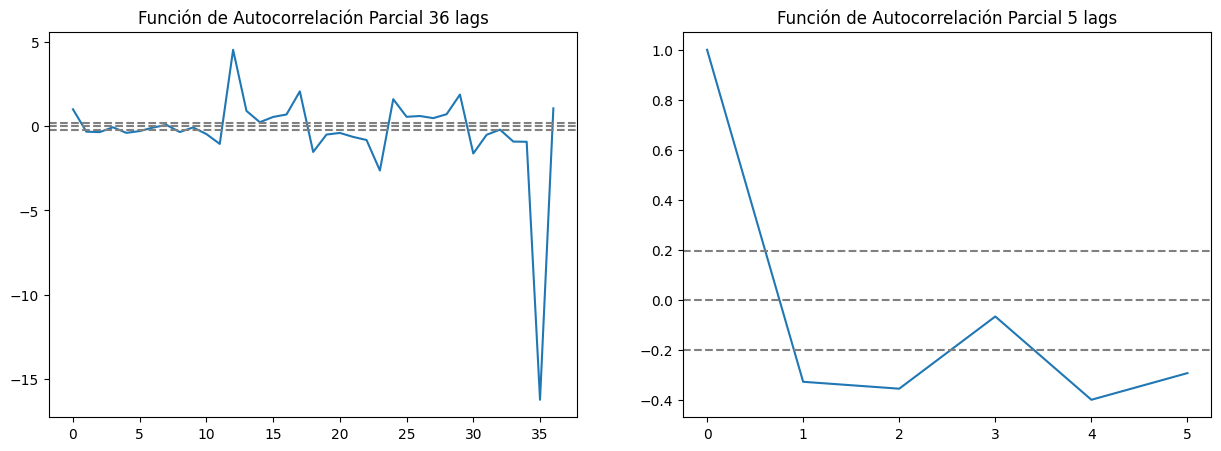

In [18]:
#plot PACF
plt.subplot(121)
plt.plot(pacf(ts_air_pas_log_diff, nlags=36))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación Parcial 36 lags')

plt.subplot(122)
plt.plot(pacf(ts_air_pas_log_diff, nlags=5))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación Parcial 5 lags')

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

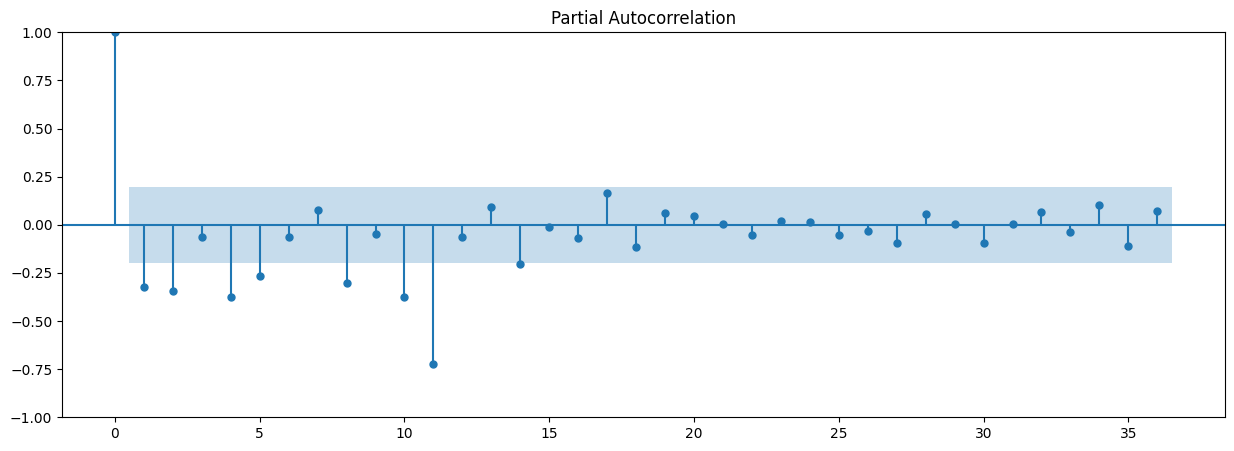

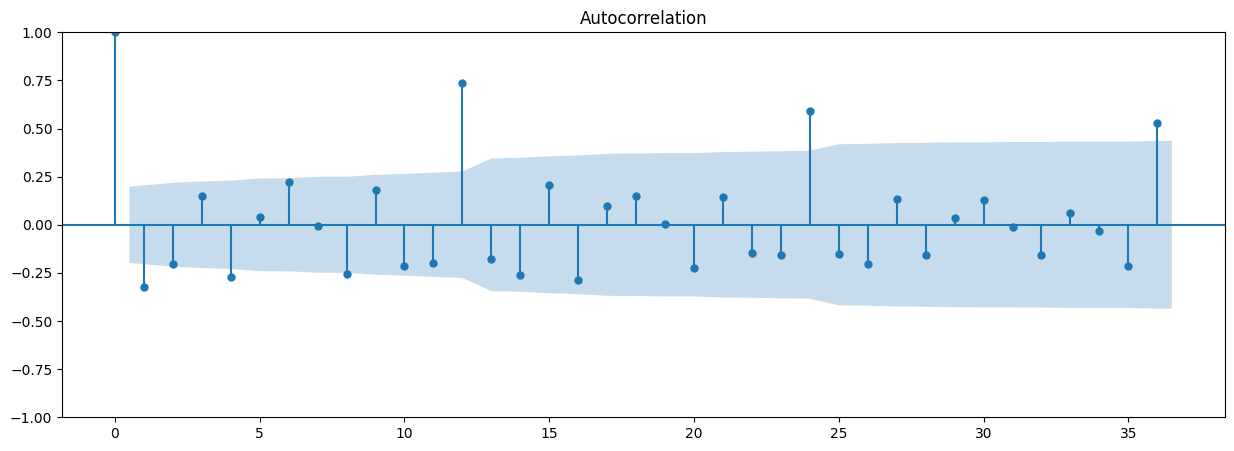

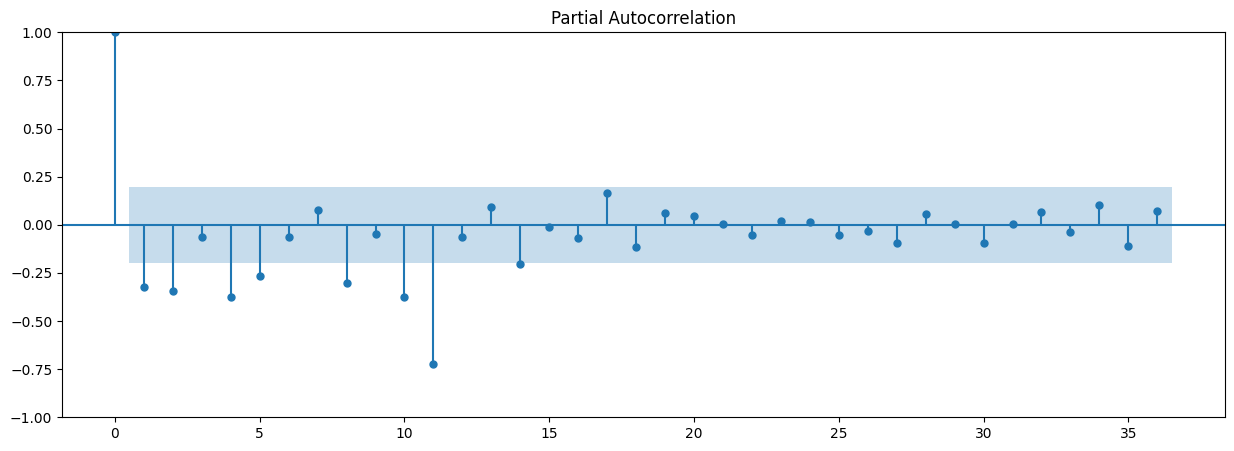

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_air_pas_log_diff, lags=36)
plot_pacf(ts_air_pas_log_diff, lags=36)

Como se ve en los gráficos de las funciones de autocorrelación y autocorrelación parcial, podemos intuir que se trata de un modelo teórico similar a un MA(q).
Podíamos probar varios modelos ARIMA:
- p=1 o 2
- q=1 o 2


#### Estacionalidad

Veamos ahora si hay estacionalidad en la serie. Hagamos un gráfico de la función de autocorrelación usando 36 resagos:


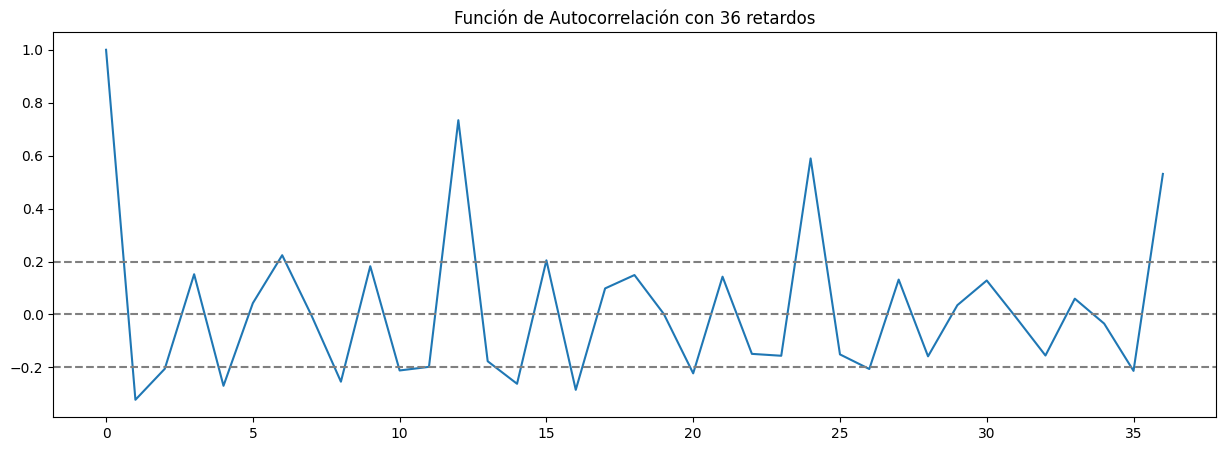

In [20]:
plt.plot(acf(ts_air_pas_log_diff,nlags=36,fft=False))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación con 36 retardos')
plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

Como se puede observar el comportamiento es similar para 12, 24, 36 meses por lo que hay una correlación entre los años, eso indica que hay estacionalidad cada 12 meses. Deberíamos agregarle el componente estacional

In [21]:
ts_air_pas_log_D = ts_air_pas_log.diff(12)
ts_air_pas_log_D.dropna(inplace=True)

Text(0.5, 1.0, 'Función de Autocorrelación Parcial 5 lags')

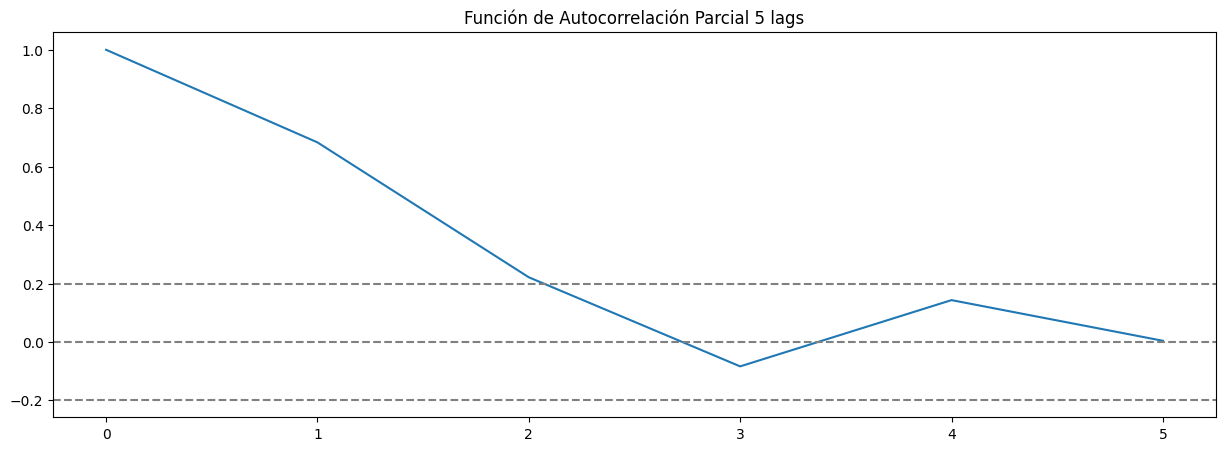

In [22]:

plt.plot(pacf(ts_air_pas_log_D, nlags=5))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación Parcial 5 lags')


Text(0.5, 1.0, 'Función de Autocorrelación - 10 lags')

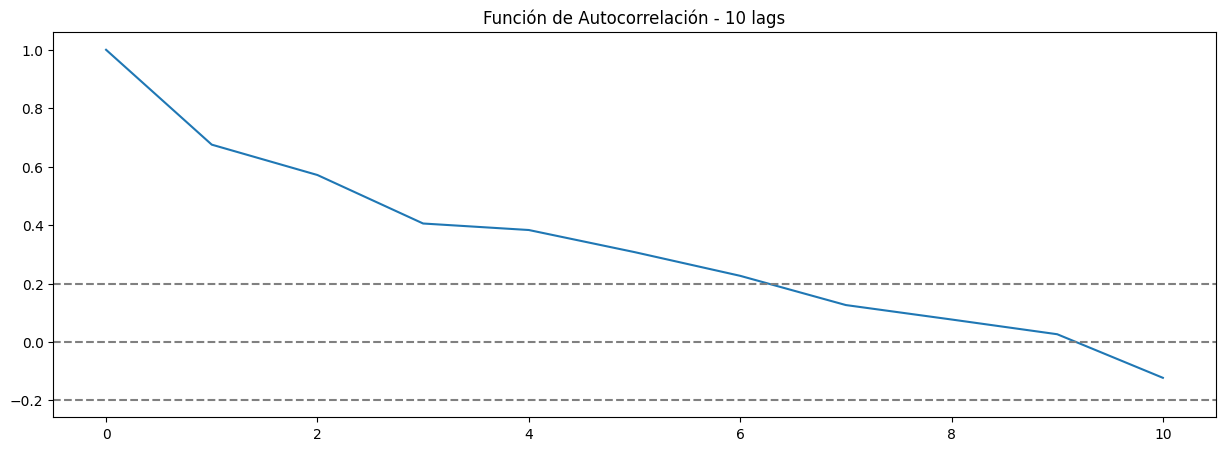

In [24]:
plt.plot(acf(ts_air_pas_log_D, nlags=10))
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_air_pas_log_diff)),linestyle='--',color='gray')
plt.title('Función de Autocorrelación - 10 lags')

Luego de hacer una diferenciación estacional, podemos observar que prácticamente se anulan los coeficientes después de p=2. Probemos el siguiente componente estacional:
- P = 2
- D = 1
- Q = 0 (no muestra un comportamiento MA)

In [33]:
modelo1 = SARIMAX(
    ts_air_pas_log,
    order=(2,1,0),
    seasonal_order=(1,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado1 = modelo1.fit()
print(resultado1.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4173      0.120     -3.488      0.000      -0.652      -0.183
ar.L2         -0.0376      0.137     -0.274      0.784      -0.306       0.231
ar.S.L12      -0.4685      0.086     -5.459      0.000      -0.637      -0.300
sigma2         0.0016      0.000      6.129      0.000       0.001       0.002


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [34]:
modelo2 = SARIMAX(
    ts_air_pas_log,
    order=(1,1,0),
    seasonal_order=(1,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado2 = modelo2.fit()
print(resultado2.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4129      0.095     -4.341      0.000      -0.599      -0.227
ar.S.L12      -0.4633      0.085     -5.474      0.000      -0.629      -0.297
sigma2         0.0016      0.000      6.178      0.000       0.001       0.002


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Análisis de residuos

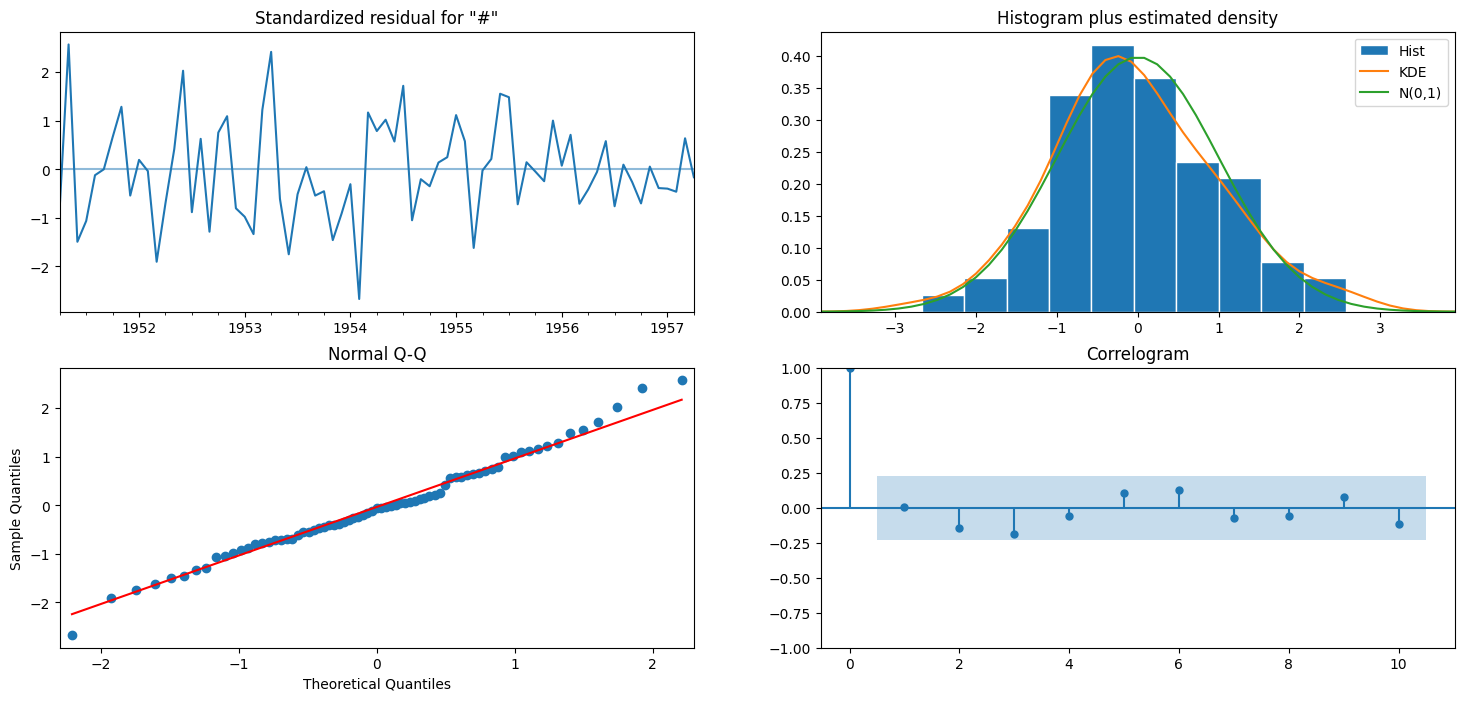

In [36]:
resultado1.plot_diagnostics(figsize=(18, 8))
plt.show()

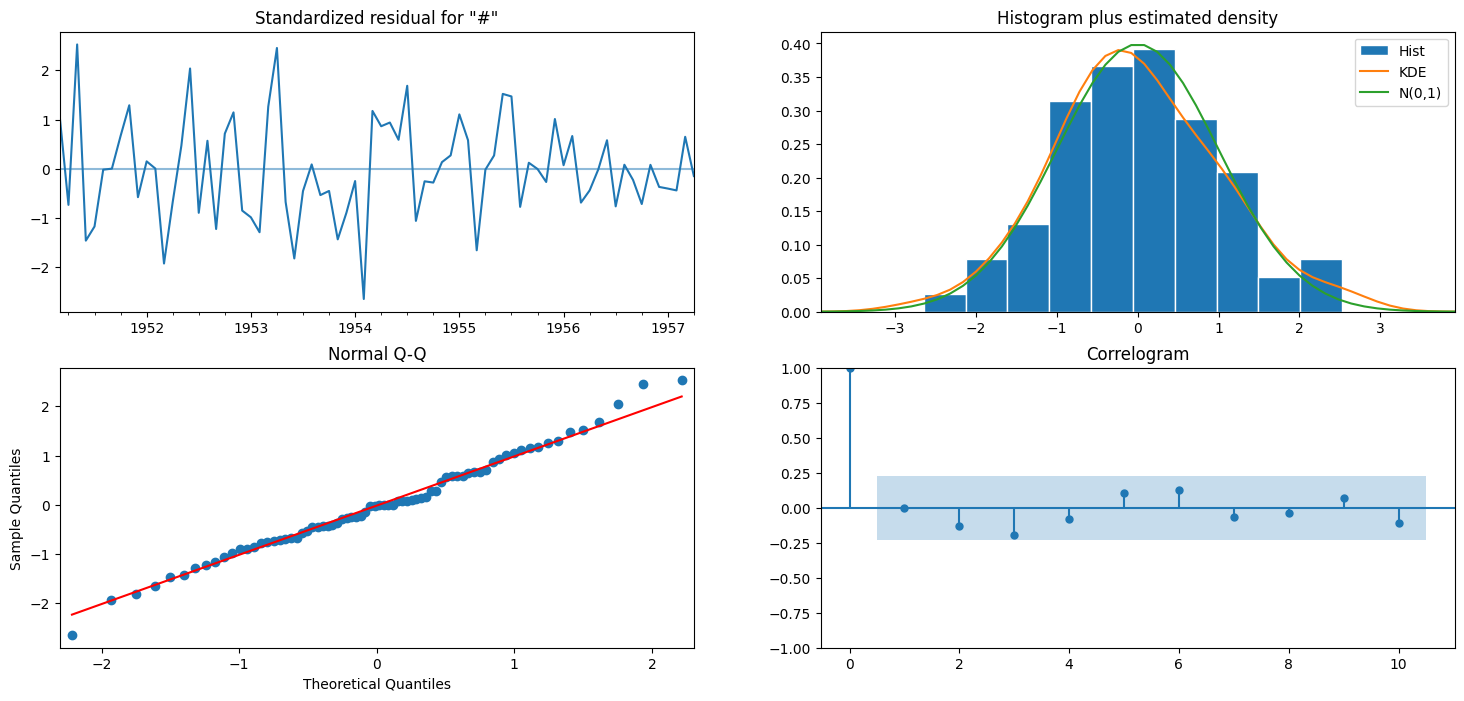

In [37]:
resultado2.plot_diagnostics(figsize=(18, 8))
plt.show()

 Como se puede obserevar:

 - el residuo estándar tiene ruidos distribuidos alrededor de cero (ruido blanco) y no siguen un patrón (bueno)
 - el histograma tiene una dist normal (bueno), los errores son normales. Si tuvieran colas gruesas o si estuviera sesgada, tendríamos un tema. 
 - el correlogram mantiene la mayoría de puntos en la banza azul. 


#### Podríamos seguir probando...

#### Analicemos errores:
#
¿Qué modelo explica mejor los datos usando la menor complejidad posible?
- AIC (qué modelo tendrá la mejor predicción) vs BIC (penaliza mucho más los modelos complejos, me quedo con el modelo menos complejo que maximice predicciones)


In [42]:
print("Resultados de AIC (Akaike information criterion)")
print("Modelo 1=",resultado1.aic)
print("Modelo 2=",resultado2.aic)
print("Resultados de BIC (Bayesian information criterion)")
print("Modelo 1=",resultado1.bic)
print("Modelo 2=",resultado2.bic)

# Buscamos coincidir ambos criterios con el valor más pequeño!

Resultados de AIC (Akaike information criterion)
Modelo 1= -253.05412619020842
Modelo 2= -258.40379951964997
Resultados de BIC (Bayesian information criterion)
Modelo 1= -243.89228842561485
Modelo 2= -251.49160424003745


Mejor modelo es el 2

## Predicción con el mejor modelo

In [44]:
test_airPas.index[0]

Timestamp('1957-05-01 00:00:00')

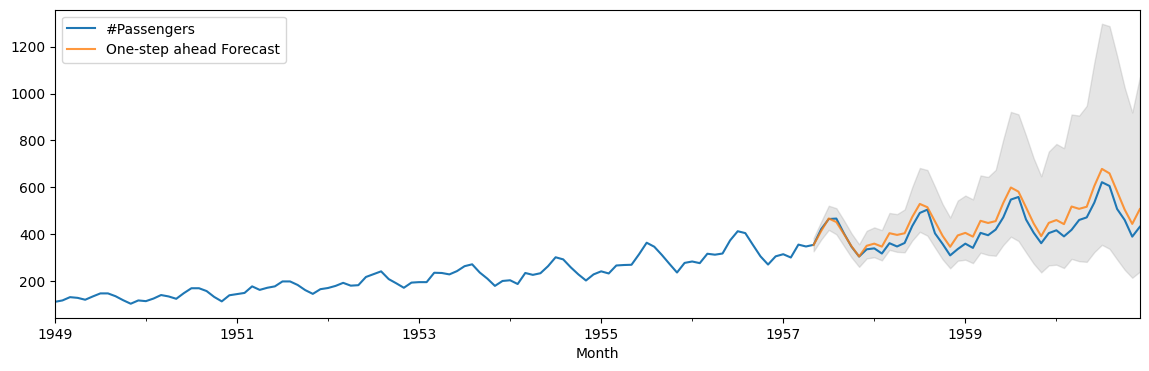

In [62]:
pred = resultado2.get_prediction(
    start=test_airPas.index[0],
    end=test_airPas.index[-1],
    dynamic=False # ojo con esto
)

# Predicción en escala original
pred_mean = np.exp(pred.predicted_mean)

# Intervalos de confianza en escala original
pred_ci = np.exp(pred.conf_int())

# Gráfica
ax = airPas['1949':].plot(
    label='Observed',
    figsize=(14,4)
)

pred_mean.plot(
    ax=ax,
    label='One-step ahead Forecast',
    alpha=0.8
)

ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='gray',
    alpha=0.2
)

plt.legend()
plt.show()

veamos ese intervalo de confianza, y los errores:

In [64]:
comparacion = pd.DataFrame({
    "Real": test_airPas["#Passengers"],
    "Predicción": pred_mean
})

comparacion["Error"] = comparacion["Real"] - comparacion["Predicción"]
comparacion["Error Absoluto"] = comparacion["Error"].abs()

print(comparacion.head())

            Real  Predicción
1957-05-01   355  354.400003
1957-06-01   422  413.888493
1957-07-01   465  467.397520
1957-08-01   467  452.125703
1957-09-01   404  401.100825
            Real  Predicción      Error  Error Absoluto
1957-05-01   355  354.400003   0.599997        0.599997
1957-06-01   422  413.888493   8.111507        8.111507
1957-07-01   465  467.397520  -2.397520        2.397520
1957-08-01   467  452.125703  14.874297       14.874297
1957-09-01   404  401.100825   2.899175        2.899175


Veamos nuestras métricas del modelo:

In [69]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    comparacion["Real"],
    comparacion["Predicción"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparacion["Real"],
        comparacion["Predicción"]
    )
)
mape = (
    np.abs(
        (comparacion["Real"] - comparacion["Predicción"])
        / comparacion["Real"]
    ).mean()
) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# ¿Cómo discutimos esto?

MAE : 39.73
RMSE: 45.34
MAPE: 9.46%
